# **Predict students' dropout and academic success**

-- ELEC3544 Group Project

---
## --------------------- Workflow ---------------------
### **Phase 1: Data Acquisition & Initial Scoping**
* **Data Ingestion:** Load the dataset and verify dimensions.
* **Target Definition:** Identify the 3-class target (`Dropout`, `Enrolled`, `Graduate`).
* **Mapping:** Convert categorical IDs into readable strings for analysis (if necessary) to ensure the EDA makes sense to a human reader.
### **Phase 2: Systematic Data Quality Assessment (Cleaning)**
* **Structure:** Check data types (Integer vs. Float). Ensure categorical variables are handled as such and not treated as continuous numbers.
* **Completeness:** Check for missing values (The UCI dataset is famously "clean," but you must demonstrate that you checked).
* **Validity:**
  * Verify numerical ranges (e.g., Grades should be between 0–20).
  * Check for logical errors (e.g., Are there students with "0 units enrolled" but a "grade of 15"?).
* **Distributional:** Check for skewness in features like `Age at enrollment`. Decide if outliers (mature students) should be capped or kept.
### **Phase 3: Exploratory Data Analysis (EDA)**
* **Correlation Block Analysis:**
  1. Academic Block: Identifying redundancy between 1st and 2nd semesters.
  2. Socio-Economic Block: Assessing parental influence.
  3. Financial Block: Testing the impact of debt/scholarships.
  4. Demographic Block: Checking for bias (`Gender` / `Age`).
* **Feature-Target Relationship:** Visualizing how the top correlated features (like *Grades* or *Tuition* status) differ across the three Target classes using Boxplots or Violin plots.
### **Phase 4: Feature Selection & Engineering**
* **Dimensionality Reduction:**
  * Drop redundant features (e.g., dropping `Nationality` if `International` provides the same info).
  * Drop low-variance features (e.g., `GDP`, `Inflation`, and `Unemployment` if they show near-zero correlation with the target).
* **Feature Construction:** (Optional) Create an "Academic Progression" feature by calculating the difference between 2nd-semester grades and 1st-semester grades.
* **Data Transformation:** Apply StandardScaler to numerical features (essential for Logistic Regression) and One-Hot Encoding for categorical features that aren't ordinal.
### **Phase 5: Model Selection & Training Strategy**
* **Baseline Model (Logistic Regression):**
  * **Goal:** Establish a "transparent" benchmark.
  * **Action:** Analyze coefficients to explain which factors increase the probability of dropout.
* **Advanced Model (Random Forest):**
  * **Goal:** Capture non-linear relationships and interactions between variables.
  * **Action:** Compare performance against the baseline.
* **Cross-Validation:** Use 5-fold Stratified Cross-Validation to ensure the model isn't just "getting lucky" on a specific slice of data.
### **Phase 6: Model Evaluation & Interpretation**
* **Metric Selection:**
  * Don't just use **Accuracy**.
  * Use a **Confusion Matrix** to see if the model confuses "Enrolled" with "Dropout."
  * Use **F1-Score** and **Recall** (Recall is critical here because missing a potential dropout is more "expensive" for a university than misidentifying a graduate).
* **Feature Importance:** Compare the "Weights" from Logistic Regression with the "Importance" from Random Forest.
### **Phase 7: Post-Mortem & Recommendations - [Coursework Conclusion]**
* **The "So What?":** Translate the math into policy. (e.g., "Since 'Tuition fees up to date' is the strongest predictor, the university should implement financial counseling for students in debt by the end of Semester 1.")
* **Limitations:** Discuss what data was missing (e.g., Mental health data or Social integration data) that could have made the model better.
* **Final Summary:** Conclude whether the project succeeded in creating an **"Early Warning System"**.

# **Step 1: Setup and Loading Data**

In [ ]:
# Install the UCI Repository library
!pip install ucimlrepo -q

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

# Fetch dataset
predict_students_dropout_and_academic_success = fetch_ucirepo(id=697)

# Data (as pandas dataframes)
df = predict_students_dropout_and_academic_success.data.features
df = df.rename(columns={'Nacionality': 'Nationality'})
target = predict_students_dropout_and_academic_success.data.targets

# Combine them for a full quality assessment
full_df = pd.concat([df, target], axis=1)

# 數值化 Target (Dropout=0, Enrolled=1, Graduate=2)
target_map = {'Dropout': 0, 'Enrolled': 1, 'Graduate': 2}
full_df['Target_num'] = full_df['Target'].map(target_map)

print("Dataset loaded successfully!")
full_df.head()

Dataset loaded successfully!


,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nationality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target,Target_num
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout,0
1,1,15,1,9254,1,1,160.0,1,1,3,...,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate,2
2,1,1,5,9070,1,1,122.0,1,37,37,...,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout,0
3,1,17,2,9773,1,1,122.0,1,38,37,...,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate,2
4,2,39,1,8014,0,1,100.0,1,37,38,...,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate,2


# **Step 2: Systematic data quality assessment**
## 1. Structure Assessment

In [ ]:
print("--- STRUCTURE ASSESSMENT ---")
# Check dimensions
print(f"Dataset Shape: {full_df.shape}")

# Check data types and memory usage
print("\nData Types and Info:")
print(full_df.info())

# Check for the column names to ensure they are clean
print("\nColumn Names:")
print(full_df.columns.tolist())

--- STRUCTURE ASSESSMENT ---
Dataset Shape: (4424, 38)

Data Types and Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 38 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital Status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nationality                                     4424 non-null   int64  
 8   Mother's qualification                   

## 2. Completeness Assessment

--- COMPLETENESS ASSESSMENT ---
Success: No missing values detected in the dataset.


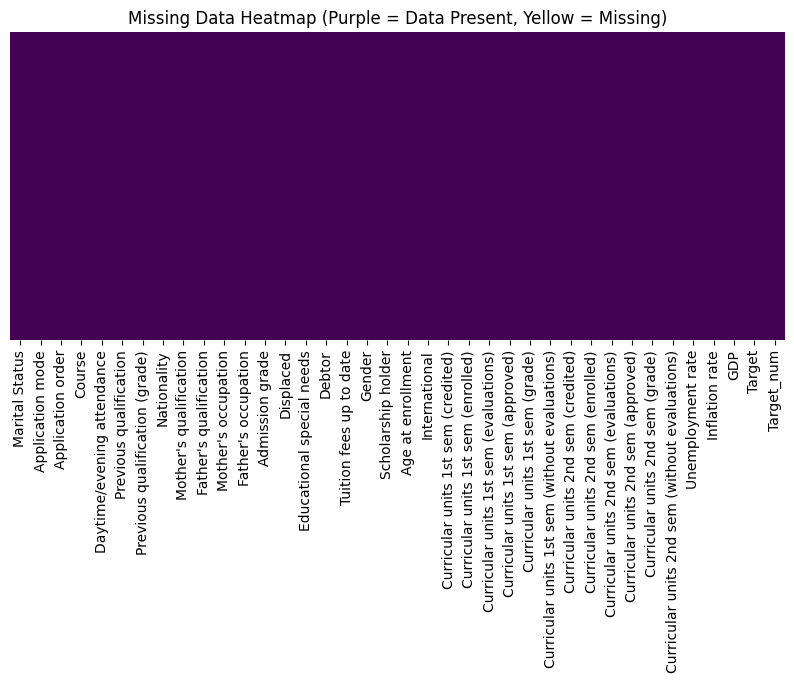

In [ ]:
print("--- COMPLETENESS ASSESSMENT ---")

# Count missing values per column
missing_values = full_df.isnull().sum()
missing_percentage = (missing_values / len(full_df)) * 100

# Display only columns that have missing values (if any)
if missing_values.sum() == 0:
    print("Success: No missing values detected in the dataset.")
else:
    print("Missing values found:")
    print(missing_values[missing_values > 0])

# Visualizing completeness (Useful for large datasets)
plt.figure(figsize=(10, 4))
sns.heatmap(full_df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title("Missing Data Heatmap (Purple = Data Present, Yellow = Missing)")
plt.show()

## 3. Validity Assessment

In [ ]:
print("--- VALIDITY ASSESSMENT ---")

# 1. Check for Duplicate Rows
duplicates = full_df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

# 2. Logical Range Check (Summary Statistics)
# We look for impossible values like negative 'Age at enrollment' or 'Curricular units 1st sem (grade)' > 20
print("\nDescriptive Statistics for Range Validation:")
display(full_df[['Age at enrollment', 'Curricular units 1st sem (grade)', 'Curricular units 2nd sem (grade)']].describe())

# 3. Categorical Validity
# Check the unique values in the Target variable
print("\nUnique values in Target (Should be Dropout, Graduate, or Enrolled):")
print(full_df['Target'].unique())

--- VALIDITY ASSESSMENT ---
Number of duplicate rows: 0

Descriptive Statistics for Range Validation:


,Age at enrollment,Curricular units 1st sem (grade),Curricular units 2nd sem (grade)
count,4424.000000,4424.000000,4424.000000
mean,23.265145,10.640822,10.230206
std,7.587816,4.843663,5.210808
min,17.000000,0.000000,0.000000
25%,19.000000,11.000000,10.750000
50%,20.000000,12.285714,12.200000
75%,25.000000,13.400000,13.333333
max,70.000000,18.875000,18.571429



Unique values in Target (Should be Dropout, Graduate, or Enrolled):
['Dropout' 'Graduate' 'Enrolled']


## 4. Distributional Assessment

--- DISTRIBUTIONAL ASSESSMENT ---


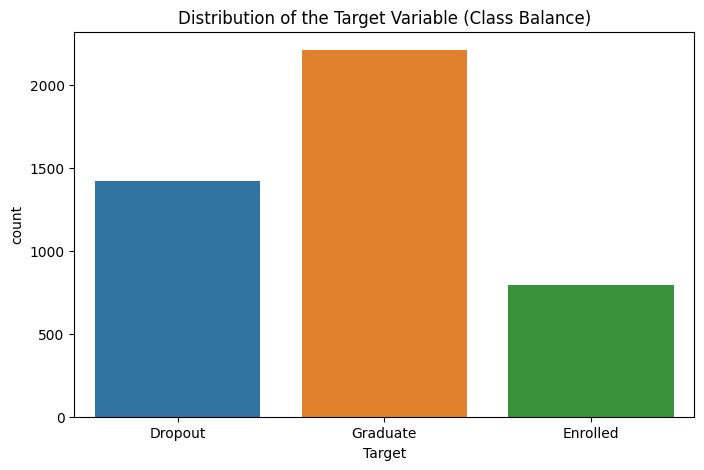

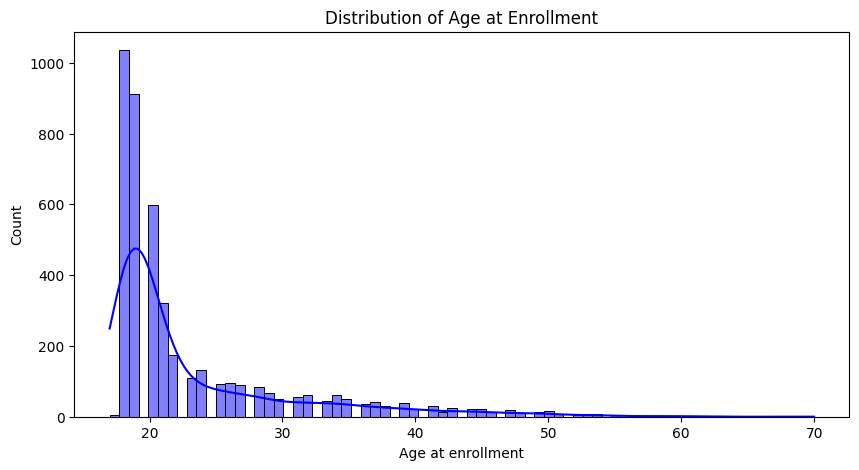

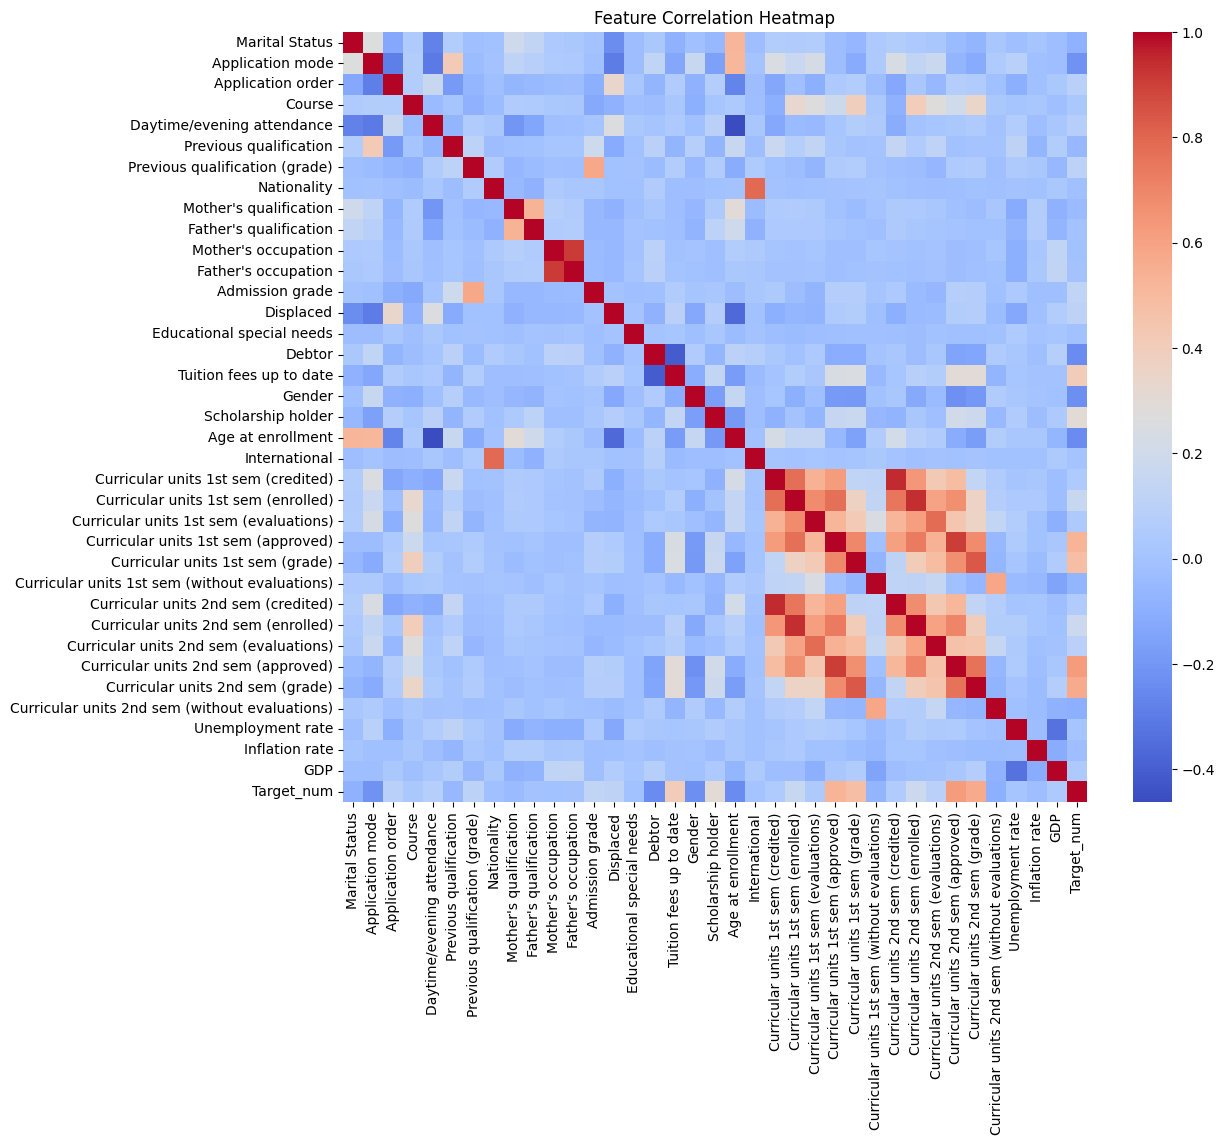

In [ ]:
print("--- DISTRIBUTIONAL ASSESSMENT ---")

# 1. Target Variable Distribution (Class Imbalance check)
plt.figure(figsize=(8, 5))
sns.countplot(x='Target',legend=False, data=full_df, hue='Target')
plt.title("Distribution of the Target Variable (Class Balance)")
plt.show()

# 2. Feature Distribution (Checking for Skewness/Outliers)
# Let's look at 'Age at enrollment'
plt.figure(figsize=(10, 5))
sns.histplot(full_df['Age at enrollment'], kde=True, color='blue')
plt.title("Distribution of Age at Enrollment")
plt.show()

# 3. Correlation check (Detecting Multicollinearity)
plt.figure(figsize=(12, 10))
# Correlation only for numerical columns
corr = full_df.select_dtypes(include=['number']).corr()
sns.heatmap(corr, annot=False, cmap='coolwarm', fmt=".1f")
plt.title("Feature Correlation Heatmap")
plt.show()

# **Part 3: Handling High Correlations**
We use 1) **DROP**, 2) **COMBINE** or 3) **KEEP** (Model Regularzation) to handle high correlations features
## 1. Academic Features

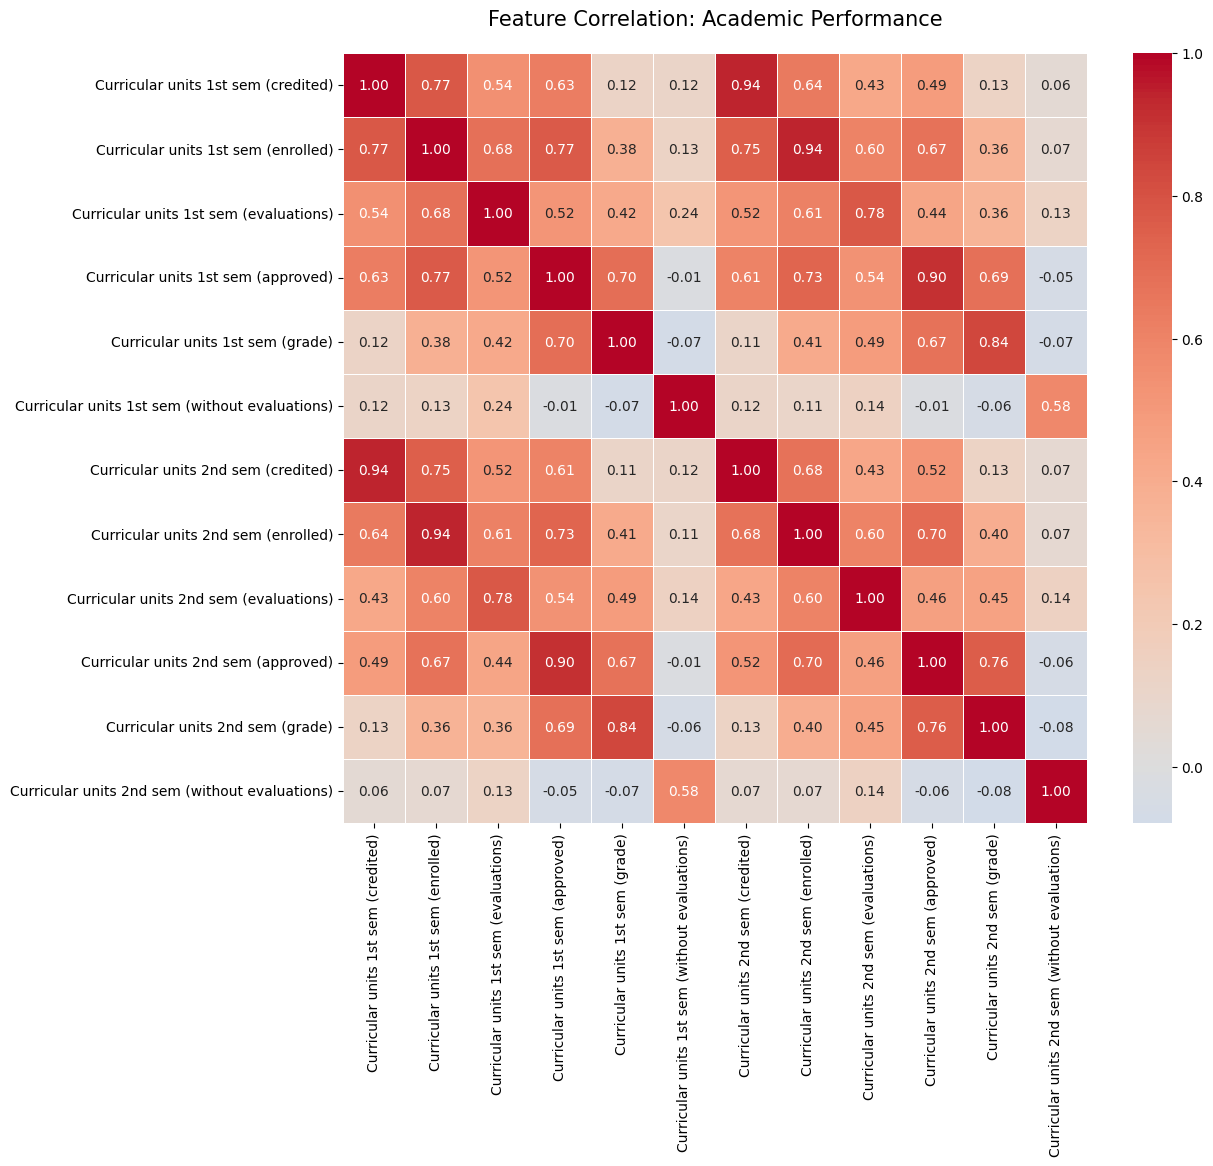

In [ ]:
# 1. Academic Features List
academic_cols = [
    'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)',
    'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)',
    'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)',
    'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)'
]
plt.figure(figsize=(12, 10))
corr_academic = full_df[academic_cols].corr()

sns.heatmap(corr_academic, annot=True, fmt=".2f", cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Feature Correlation: Academic Performance', fontsize=15, pad=20)
plt.show()

# Insight: Look for values > 0.80. These are candidates for combining into an "Annual Average".

### Feature Engineering (Combining features)
**Feature Engineering Strategy**: Instead of using raw semester-wise data which exhibited high multicollinearity, we synthesized four behavioral metrics: **Grade Trend, Approved Difference, Success Rate, and Average Grade**. This approach reduces the feature space while emphasizing the dynamic academic progression of students, which is hypothesized to be a stronger predictor of dropout than static semester snapshots.

In [ ]:
import pandas as pd
import numpy as np

# 1. 創建新的工程特徵 (New Engineered Features)

# A. 成績趨勢：正值代表進步，負值代表退步
full_df['Grade_Trend'] = full_df['Curricular units 2nd sem (grade)'] - full_df['Curricular units 1st sem (grade)']

# B. 學分通過差異：觀察學生是否在第二學期適應得更好
full_df['Approved_Diff'] = full_df['Curricular units 2nd sem (approved)'] - full_df['Curricular units 1st sem (approved)']

# C. 學分成功率 (Success Rate)：總共通過多少 / 總共註冊多少
# 注意：為了避免除以零，加上一個極小值 epsilon
total_enrolled = full_df['Curricular units 1st sem (enrolled)'] + full_df['Curricular units 2nd sem (enrolled)']
total_approved = full_df['Curricular units 1st sem (approved)'] + full_df['Curricular units 2nd sem (approved)']
full_df['Credit_Success_Rate'] = total_approved / (total_enrolled + 1e-5)

# D. 平均學術表現
full_df['Avg_Grade'] = (full_df['Curricular units 1st sem (grade)'] + full_df['Curricular units 2nd sem (grade)']) / 2

# 2. 定義需要移除的原始高相關特徵 (原本那 12 個)
original_academic_cols = [col for col in full_df.columns if 'sem' in col]

# 3. 建立簡化後的 dataframe 用於後續建模
# 我們保留新特徵，移除舊的學術特徵
reduced_df = full_df.drop(columns=academic_cols)

print("New features have been established, and the original academic features have been removed.")
print(f"Number of features remaining: {len(reduced_df.columns)}")
reduced_df[['Grade_Trend', 'Approved_Diff', 'Credit_Success_Rate', 'Avg_Grade']].head()

New features have been established, and the original academic features have been removed.
Number of features remaining: 30


,Grade_Trend,Approved_Diff,Credit_Success_Rate,Avg_Grade
0,0.000000,0,0.000000,0.000000
1,-0.333333,0,0.999999,13.833333
2,0.000000,0,0.000000,0.000000
3,-1.028571,-1,0.916666,12.914286
4,0.666667,1,0.916666,12.666667


**Verify: Correlation between engineered features & target**

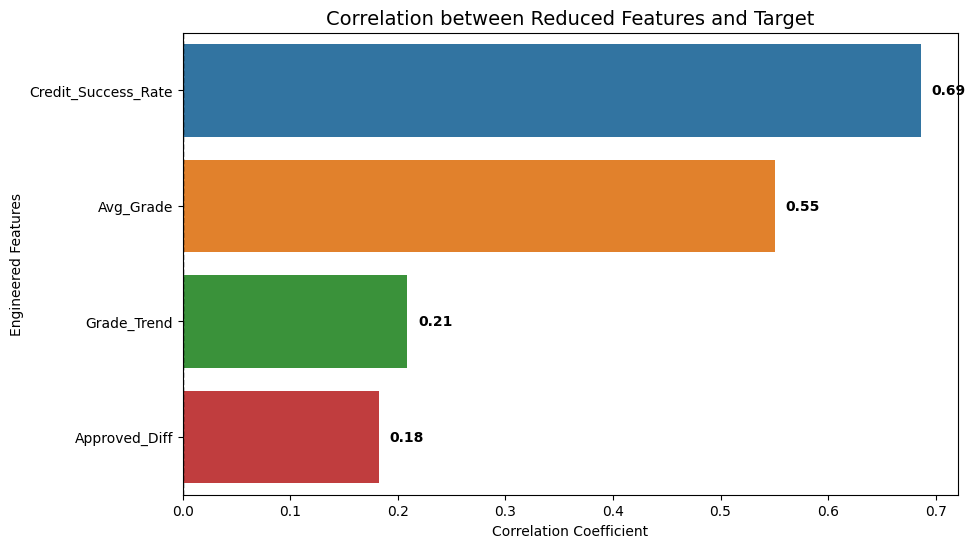

In [ ]:
# 1. 確保 Target 已數值化 (Dropout=0, Enrolled=1, Graduate=2)
# 如果之前已經做過，這行會直接執行
if 'Target_num' not in full_df.columns:
    target_map = {'Dropout': 0, 'Enrolled': 1, 'Graduate': 2}
    full_df['Target_num'] = full_df['Target'].map(target_map)

# 2. 定義你建立的簡化特徵列表
reduced_features = ['Grade_Trend', 'Approved_Diff', 'Credit_Success_Rate', 'Avg_Grade']

# 3. 計算相關性矩陣，並只提取與 Target_num 相關的那一列
correlation_with_target = full_df[reduced_features + ['Target_num']].corr()['Target_num'].drop('Target_num')

# 4. 排序以利觀察
correlation_with_target = correlation_with_target.sort_values(ascending=False)

# 5. 繪製條形圖 (視覺上比熱圖更直觀地對比各特徵的貢獻)
plt.figure(figsize=(10, 6))
sns.barplot(x=correlation_with_target.values, y=correlation_with_target.index, hue=correlation_with_target.index, legend=False)

# 加上數值標籤
for i, v in enumerate(correlation_with_target.values):
    plt.text(v + 0.01, i, f'{v:.2f}', color='black', va='center', fontweight='bold')

plt.title('Correlation between Reduced Features and Target', fontsize=14)
plt.xlabel('Correlation Coefficient')
plt.ylabel('Engineered Features')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1) # 增加中心線
plt.show()

## 2. Socio-Economic Features

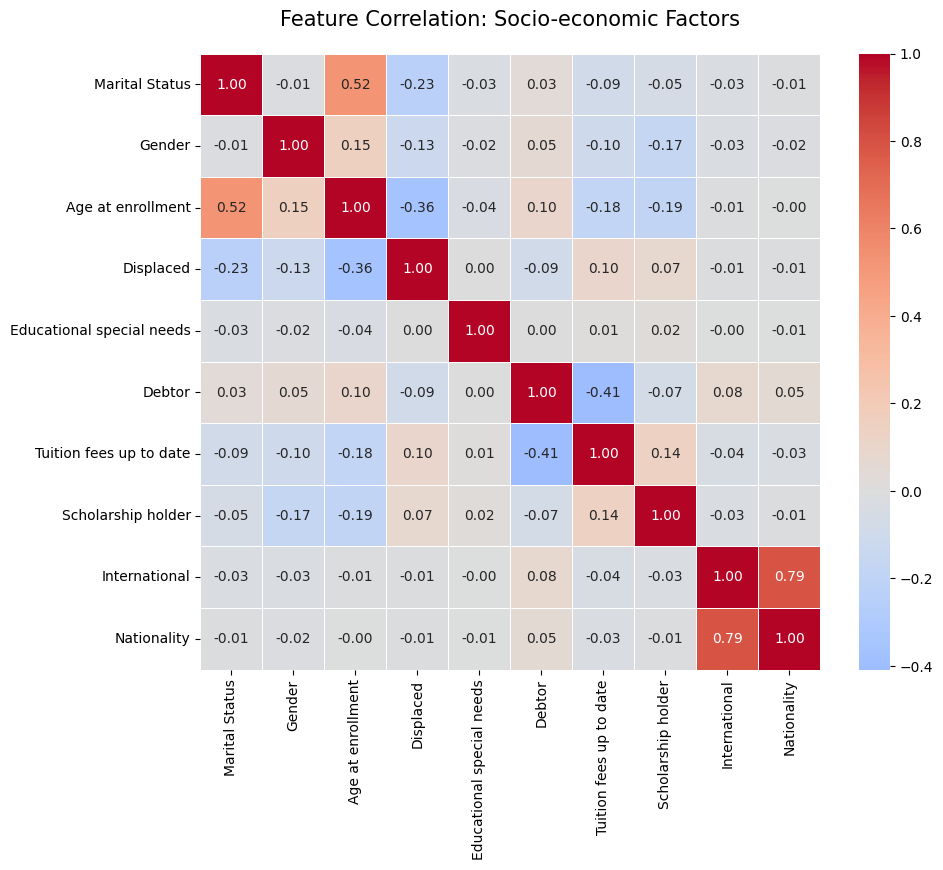

In [ ]:
# 2. Socio-economic Features
socio_cols = [
    'Marital Status', 'Gender', 'Age at enrollment', 'Displaced',
    'Educational special needs', 'Debtor', 'Tuition fees up to date',
    'Scholarship holder', 'International', 'Nationality'
]

plt.figure(figsize=(10, 8))
corr_socio = full_df[socio_cols].corr()
mask = np.triu(np.ones_like(corr_socio, dtype=bool))

sns.heatmap(corr_socio, annot=True, fmt=".2f", cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Feature Correlation: Socio-economic Factors', fontsize=15, pad=20)
plt.show()

# Insight: Often Mother's and Father's qualifications are correlated.
# You might simplify this later to "Highest Parental Education Level".

We shall remove **Nationality** as it is redundant with "International"

In [ ]:
if "Nationality" in reduced_df.columns:
    reduced_df = reduced_df.drop(columns=["Nationality"])


print("Removed Nationality")
print(f"- Number of features remaining: {len(reduced_df.columns)}")

Removed Nationality
- Number of features remaining: 29


## 3. Enrollment Features

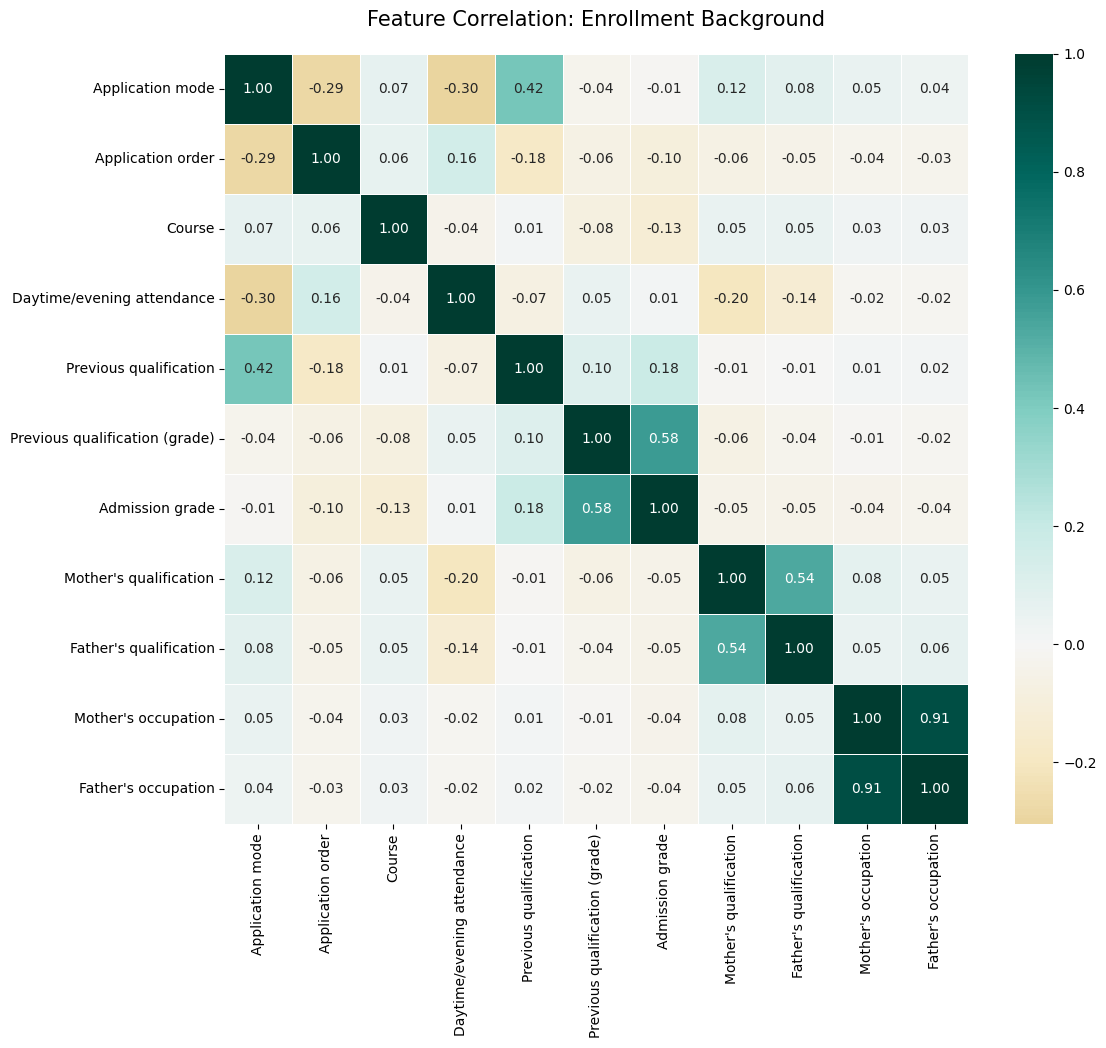

In [ ]:
# 3. Enrollment Features List
background_cols = [
    'Application mode', 'Application order', 'Course',
    'Daytime/evening attendance', 'Previous qualification',
    'Previous qualification (grade)', 'Admission grade',
    'Mother\'s qualification', 'Father\'s qualification',
    'Mother\'s occupation', 'Father\'s occupation'
]

plt.figure(figsize=(12, 10))
corr_back = full_df[background_cols].corr()
mask = np.triu(np.ones_like(corr_back, dtype=bool))

sns.heatmap(corr_back, annot=True, fmt=".2f", cmap='BrBG', center=0, linewidths=0.5)
plt.title('Feature Correlation: Enrollment Background', fontsize=15, pad=20)
plt.show()

# Insight: 'Debtor' and 'Tuition fees up to date' usually have a strong negative correlation.
# If a student is a debtor, their fees are likely not up to date.

We shall remove **Father's occupation** as it indicating extreme redundancy

In [ ]:
# 1. 處理父母職業的高相關性 (0.91)
# 由於兩者極度冗餘，我們移除 Father's occupation
if "Father's occupation" in reduced_df.columns:
    reduced_df = reduced_df.drop(columns=["Father's occupation"])

# 2. 關於父母學歷 (0.54) 和成績 (0.58)，我們選擇保留
# 因為它們保留了足夠的獨立資訊 (Unique Information)

print("- Removed Father's occupation (r=0.91)。")
print(f"- Number of features remaining: {len(reduced_df.columns)}")

- Removed Father's occupation (r=0.91)。
- Number of features remaining: 28


## 4. Macroeconomic Features

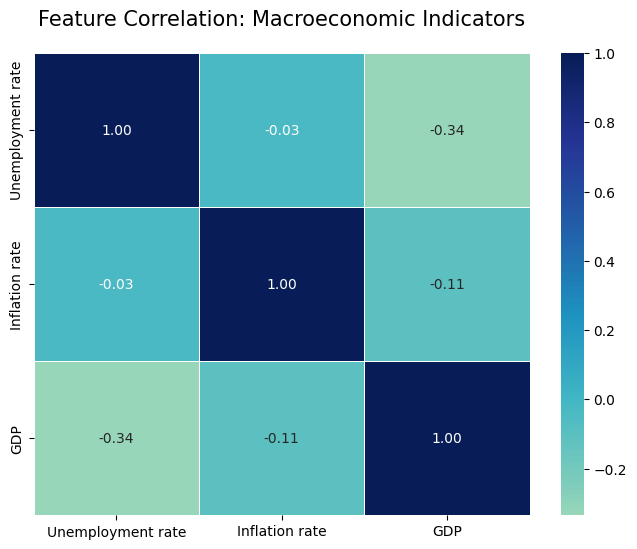

In [ ]:
# 4. Macroeconomic Features List
macro_cols = ['Unemployment rate', 'Inflation rate', 'GDP']

plt.figure(figsize=(8, 6))
corr_macro = full_df[macro_cols].corr()
mask = np.triu(np.ones_like(corr_macro, dtype=bool))

sns.heatmap(corr_macro, annot=True, fmt=".2f", cmap='YlGnBu', center=0, linewidths=0.5)
plt.title('Feature Correlation: Macroeconomic Indicators', fontsize=15, pad=20)
plt.show()

# Insight: 'Nacionality' and 'International' will have near-perfect correlation.
# You should definitely drop one of these two to avoid redundancy.

### **GDP, Unemployment rate, and Inflation rate**

While they are included in the original UCI dataset to provide "macro-economic context," they are frequently dropped or ignored for four specific reasons:

1. The "Granularity Mismatch"
GDP is a macro-level variable (national level), while dropout is a micro-level event (individual level). The Problem: In this dataset, every student who enrolled in the same year is assigned the exact same GDP and Unemployment value. The Result: The model struggles to learn from this because the feature doesn't vary between the "Success" student and the "Dropout" student who started in the same semester. It lacks "discriminatory power."

2. Lack of Variance
Because the data was collected over a limited number of years, there are only a handful of unique values for GDP in the entire column of thousands of rows.If a feature is almost a constant (or has very few levels), it provides almost zero information to a machine learning model.

3. Indirect vs. Direct Influence (Proxies)
Macro-economic factors like GDP do affect students, but they do so indirectly.Example: A low GDP might lead to a student's father losing his job, which makes the student a "Debtor." The Dataset Logic: Since the dataset already contains direct variables like "Debtor," "Scholarship holder," and "Tuition fees up to date," the "GDP" variable becomes redundant. The direct variables "absorb" the impact of the macro-economic ones.
4. Multicollinearity with other Macro-features
GDP, Unemployment, and Inflation are usually highly correlated with each other (as one goes down, the others move in predictable ways). Including all three can cause mathematical instability in models like Logistic Regression.

/tmp/ipykernel_1119/3853860225.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=macro_corr.values, y=macro_corr.index, palette='magma')


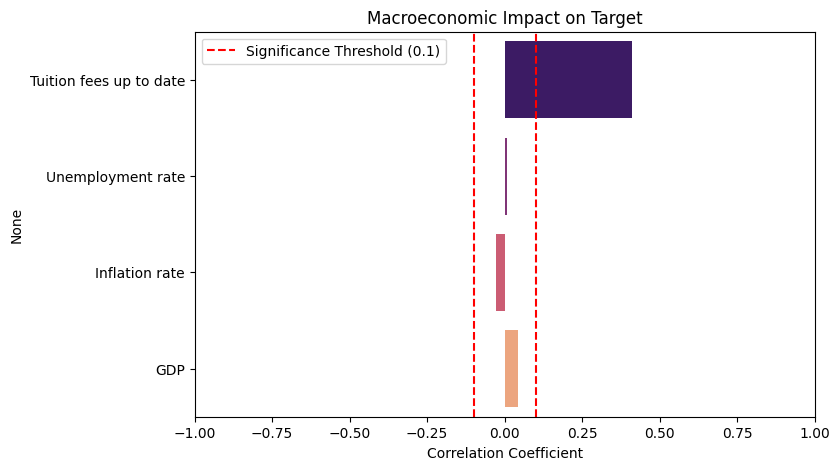

Macroeconomic features show a low correlation with target (Lower than threshold, 0.1)


In [ ]:
# 1. 篩選宏觀經濟特徵
macro_cols = ['Tuition fees up to date', 'Unemployment rate', 'Inflation rate', 'GDP', 'Target_num']
macro_corr = full_df[macro_cols].corr()['Target_num'].drop('Target_num')

# 2. 繪圖
plt.figure(figsize=(8, 5))
sns.barplot(x=macro_corr.values, y=macro_corr.index, palette='magma')
plt.axvline(x=0.1, color='red', linestyle='--', label='Significance Threshold (0.1)')
plt.axvline(x=-0.1, color='red', linestyle='--')
plt.title('Macroeconomic Impact on Target', fontsize=12)
plt.xlabel('Correlation Coefficient')
plt.xlim(-1, 1) # 統一量程以顯示其微小
plt.legend()
plt.show()

print("Macroeconomic features show a low correlation with target (Lower than threshold, 0.1)")

*   **Tuition fees up to date:** Usually has a high correlation (approx **0.40+**) with success.
* **GDP:** Usually has a very near-zero correlation (approx **0.04**) with success.

**Verdict for your project:**
* If you are using **Linear Models** (Logistic Regression, SVM), you should **drop** GDP/Unemployment/Inflation to keep the model simple.
* If you are using **Tree-based Models** (Random Forest, XGBoost), you can **keep** them; the model will simply ignore them or give them a "Feature Importance" score of nearly zero, so they won't do much harm, but they won't help much either.

In [ ]:
# 移除所有宏觀經濟特徵
macro_to_drop = ['Unemployment rate', 'Inflation rate', 'GDP']
reduced_df = reduced_df.drop(columns=[col for col in macro_to_drop if col in reduced_df.columns])

print(f"Macroeconomic features (3) are removed. Remaining: {len(reduced_df.columns)}")

Macroeconomic features (3) are removed. Remaining: 25


### **Preparing for modeling - Clean Target**

In [ ]:
# 1. 移除原始的字串 Target 欄位
if 'Target' in reduced_df.columns:
    reduced_df = reduced_df.drop(columns=['Target'])

# 2. 將 Target_num 重新命名回 Target
if 'Target_num' in reduced_df.columns:
    reduced_df = reduced_df.rename(columns={'Target_num': 'Target'})

print(f"Final Number of features remaining: {len(reduced_df.columns)}")
print(reduced_df.info())

Final Number of features remaining: 24
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 24 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Marital Status                  4424 non-null   int64  
 1   Application mode                4424 non-null   int64  
 2   Application order               4424 non-null   int64  
 3   Course                          4424 non-null   int64  
 4   Daytime/evening attendance      4424 non-null   int64  
 5   Previous qualification          4424 non-null   int64  
 6   Previous qualification (grade)  4424 non-null   float64
 7   Mother's qualification          4424 non-null   int64  
 8   Father's qualification          4424 non-null   int64  
 9   Mother's occupation             4424 non-null   int64  
 10  Admission grade                 4424 non-null   float64
 11  Displaced                       4424 non-null   int64  


### **Categorical Encoding: One-Hot Encoding**

In [ ]:
# 定義需要進行 One-Hot Encoding 的類別特徵
categorical_features = [
    'Marital Status', 'Application mode', 'Course',
    'Previous qualification', "Mother's qualification",
    "Father's qualification", "Mother's occupation"
]

# 使用 pandas 的 get_dummies 進行轉換
df_final = pd.get_dummies(reduced_df, columns=categorical_features, drop_first=True)

print(f"Dimention after One-Hot Encoding: {df_final.shape}")

Dimention after One-Hot Encoding: (4424, 163)


### **Feature Scaling: Standardization**

In [ ]:
from sklearn.preprocessing import StandardScaler

# 排除 Target 欄位
X = df_final.drop(columns=['Target'])
y = df_final['Target']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 轉回 DataFrame 方便觀察
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# **Part 4: Choosing a regression model**
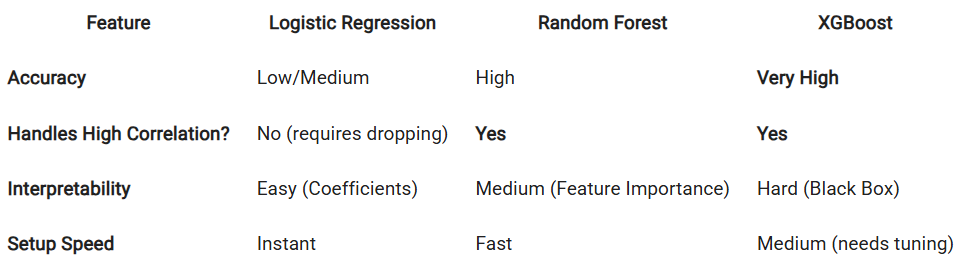

**Train-Test Split**

In [ ]:
from sklearn.model_selection import train_test_split

# Mapping: 0 for Dropout, 1 for Success (combining Enrolled and Graduate)
y_binary = y.map({0: 0, 1: 1, 2: 1})

X_train, X_test, y_train_binary, y_test_binary = train_test_split(
    X_scaled_df, y_binary, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {len(X_train)}")
print(f"Test: {len(X_test)}")

Train: 3539
Test: 885


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# 建立一個評估 FUNCTION
def evaluate_model(model, X_test, y_test, model_name="Model"):
    y_pred = model.predict(X_test)
    # 定義對應的名稱
    target_names = ['Dropout', 'Success']

    print(f"--- {model_name} Evaluation ---")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=target_names))

    # 繪製混淆矩陣
    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(y_test, y_pred)

    # 使用 target_names 作為軸標籤
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names,
                yticklabels=target_names)

    plt.xlabel('Predicted', fontsize=12)
    plt.ylabel('True', fontsize=12)
    plt.title(f'Confusion Matrix: {model_name}', fontsize=14)
    plt.show()

## **Baseline (Logistic Regression)**

--- Logistic Regression Evaluation ---
Accuracy: 0.8452

Classification Report:
              precision    recall  f1-score   support

     Dropout       0.74      0.81      0.77       284
     Success       0.90      0.86      0.88       601

    accuracy                           0.85       885
   macro avg       0.82      0.83      0.83       885
weighted avg       0.85      0.85      0.85       885



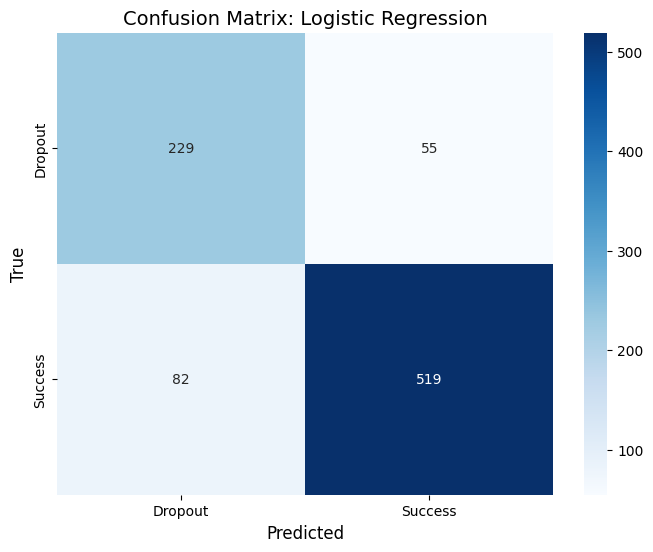

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# 1. 初始化模型
# max_iter 設為 1000 確保梯度下降能收斂
# Using 'liblinear' for small-to-medium datasets; 'max_iter' increased for convergence
# 使用 'balanced' 讓模型自動根據樣本比例分配權重
log_model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')

# 2. 訓練模型
log_model.fit(X_train, y_train_binary)

# 3. 使用我們之前的評估函數
evaluate_model(log_model, X_test, y_test_binary, model_name="Logistic Regression")

In [ ]:
# 提取對預測 "Dropout" (類別 0) 貢獻最大的特徵
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': log_model.coef_[0]  # 指向 Dropout 類別
})

# 1. 建立對應字典 (根據官方 Metadata)
mapping_dict = {
    # Core Academic & Financial Features
    'Tuition fees up to date': 'Financial: Tuition Paid up to Date',
    'Debtor': 'Financial: Debt Owed (Debtor)',
    'Scholarship holder': 'Financial: Scholarship Holder',

    # Course / Major Information
    'Course_171': 'Course 171: Animation & Multimedia Design',
    'Course_9853': 'Course 9853: Social Service',
    'Course_9130': 'Course 9130: Equiniculture (Horse Management)',
    'Course_9773': 'Course 9773: Journalism and Communication',
    'Course_9991': 'Course 9991: Management (Evening)',
    'Course_9500': 'Course 9500: Nursing',

    # Demographic & Application Mode
    'Age at enrollment': 'Demographic: Age at Enrollment',
    'Application mode_39': 'Application Mode: Mature Student (Over 23 Entry)',
    'Application mode_53': 'Application Mode: Short Cycle Diploma Holders',
    'Previous qualification_4': 'Prev Qual: High School Incomplete',

    # Maternal Background (Occupation - Crucial for your LogReg results)
    'Mother\'s occupation_9': 'Mother\'s Job: Scientific/Intellectual Profession',
    'Mother\'s occupation_4': 'Mother\'s Job: Administrative Staff',
    'Mother\'s occupation_134': 'Mother\'s Job: Skilled Worker (Industry)',
    'Mother\'s occupation_144': 'Mother\'s Job: Manual Worker (Agriculture/Fishery)',
    'Mother\'s occupation_191': 'Mother\'s Job: Unskilled Worker (Services)',
    'Mother\'s occupation_90': 'Mother\'s Job: Other Unskilled Worker',

    # Parental Education (Qualification)
    'Mother\'s qualification_11': 'Mother\'s Edu: Primary Education (1st Cycle)',
    'Mother\'s qualification_34': 'Mother\'s Edu: Higher Education (Degree)',
    'Father\'s qualification_34': 'Father\'s Edu: Unknown', # Based on common UCI encoding 34 is often Higher Ed or Unknown; please verify with your metadata
}

# 2. 處理你的特徵係數結果
# 假設你的特徵係數儲存在 feature_importance 這個 DataFrame 中
feature_importance['Factor'] = feature_importance['Feature'].map(mapping_dict).fillna(feature_importance['Feature'])

# 3. 重新排序並顯示
top_10_mapped = feature_importance.sort_values(by='Coefficient', ascending=False).head(10)

print("--- Top 10 Factors Leading to Dropout ---")
print(top_10_mapped[['Factor', 'Coefficient']])

--- Top 10 Factors Leading to Dropout ---
                                             Factor  Coefficient
14                              Credit_Success_Rate     1.975923
7                Financial: Tuition Paid up to Date     0.767217
158          Mom's Job: Unskilled Worker (Services)     0.610747
38        Course 171: Animation & Multimedia Design     0.550251
139   Mom's Job: Scientific/Intellectual Profession     0.398394
134                 Mom's Job: Administrative Staff     0.316369
36    Application Mode: Short Cycle Diploma Holders     0.278343
13                                    Approved_Diff     0.277627
151  Mom's Job: Manual Worker (Agriculture/Fishery)     0.274619
148            Mom's Job: Skilled Worker (Industry)     0.263262


## **Random Forest**

--- Random Forest Evaluation ---
Accuracy: 0.8588

Classification Report:
              precision    recall  f1-score   support

     Dropout       0.76      0.82      0.79       284
     Success       0.91      0.88      0.89       601

    accuracy                           0.86       885
   macro avg       0.84      0.85      0.84       885
weighted avg       0.86      0.86      0.86       885



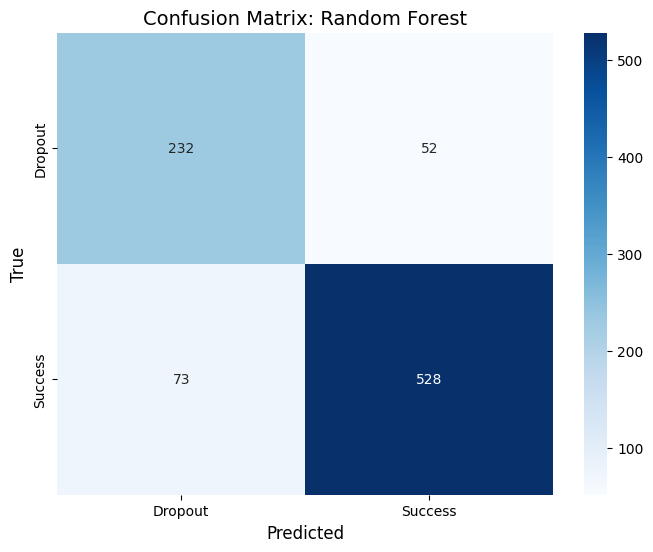

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# 1. 初始化模型
# n_estimators=100 代表建立 100 棵樹
# random_state=42 確保每次跑的結果都一樣，方便寫報告
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', max_depth=10, random_state=42)

# 2. 訓練模型
rf_model.fit(X_train, y_train_binary)

# 3. 使用我們之前的評估函數
evaluate_model(rf_model, X_test, y_test_binary, model_name="Random Forest")

In [ ]:
# 提取特徵重要性
rf_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
})

# 排序並取前 10 名
top_10_rf = rf_importance.sort_values(by='Importance', ascending=False).head(10)

# 加入我們之前的 Mapping 描述，讓結果更好讀
top_10_rf['Factor'] = top_10_rf['Feature'].map(mapping_dict).fillna(top_10_rf['Feature'])

print("--- Random Forest Top 10 Feature Importance ---")
print(top_10_rf[['Factor', 'Importance']])

--- Random Forest Top 10 Feature Importance ---
                                Factor  Importance
14                 Credit_Success_Rate    0.326042
15                           Avg_Grade    0.185061
7   Financial: Tuition Paid up to Date    0.072186
12                         Grade_Trend    0.052337
10      Demographic: Age at Enrollment    0.044631
6        Financial: Debt Owed (Debtor)    0.025143
13                       Approved_Diff    0.024789
9        Financial: Scholarship Holder    0.024504
3                      Admission grade    0.023468
2       Previous qualification (grade)    0.021039


**For Random Forest, the top 3 are our engineered features!!!**

# **Part 5: Live Demo Predictor**

In [ ]:
def live_predictor_hku_style():
    print("--- 🎓 Student Success Prediction (HKU Edition) ---")
    print("Please enter the academic details (GPA 4.3 Scale):")

    try:
        # 1. Inputs using local campus standards
        total_courses = float(input("How many courses did you take this year? (e.g., 10): "))
        passed_courses = float(input("How many courses did you pass? (e.g., 8): "))

        gpa_sem1 = float(input("GPA in Semester 1 (0 - 4.3): "))
        gpa_sem2 = float(input("GPA in Semester 2 (0 - 4.3): "))

        age = float(input("Age at enrollment (e.g., 18): "))
        tuition_val = float(input("Tuition fees settled? (1: Yes, 0: No): "))

        # 2. Conversion Logic to match original dataset (0-20 scale)
        # Mapping GPA 4.3 to 20 scale
        score_sem1 = (gpa_sem1 / 4.3) * 20
        score_sem2 = (gpa_sem2 / 4.3) * 20

        # Mapping Credits (6 units per course)
        # Note: Success Rate remains the same regardless of multiplier
        success_rate = passed_courses / total_courses if total_courses > 0 else 0
        avg_grade = (score_sem1 + score_sem2) / 2
        grade_trend = score_sem2 - score_sem1

        # 3. Prepare Feature Vector
        sample_data = X_train.mean().to_frame().T

        # 4. Fill with converted values
        sample_data['Credit_Success_Rate'] = success_rate
        sample_data['Avg_Grade'] = avg_grade
        sample_data['Grade_Trend'] = grade_trend
        sample_data['Age at enrollment'] = age
        sample_data['Tuition fees up to date'] = tuition_val

        # 5. Scaling and Prediction
        sample_scaled_array = scaler.transform(sample_data)
        sample_scaled_df = pd.DataFrame(sample_scaled_array, columns=X_train.columns)

        prediction = rf_model.predict(sample_scaled_df)[0]
        probability = rf_model.predict_proba(sample_scaled_df)[0]

        # 6. Output mapping
        target_map = {0: "DROPOUT (High Risk)",
                      1: "SUCCESS (Stay / Graduate)"}

        print("-"*50)
        print(f"Calculated to fit European model:")
        print(f"Average Grade (20 Credit System): {avg_grade:.2f}/20")
        print(f"Course Pass Rate: {success_rate*100:.1f}% ({int(passed_courses)}/{int(total_courses)})")
        print("\n" + "*" * 50)
        print("               ASSESSMENT RESULT")
        print("*" * 50)
        print(f"Final Prediction: {target_map[prediction]}")
        print(f"Model Confidence: {probability[prediction]*100:.2f}%")
        print("*"*50)

    except ValueError:
        print("Error: Please check your input format.")

# Run the localized predictor
live_predictor_hku_style()

--- 🎓 Student Success Prediction (HKU Edition) ---
Please enter the academic details (GPA 4.3 Scale):
How many courses did you take this year? (e.g., 10): 10
How many courses did you pass? (e.g., 8): 10
GPA in Semester 1 (0 - 4.3): 2.0
GPA in Semester 2 (0 - 4.3): 2.2
Age at enrollment (e.g., 18): 19
Tuition fees settled? (1: Yes, 0: No): 1
--------------------------------------------------
Calculated to fit European model:
Average Grade (20 Credit System): 9.77/20
Course Pass Rate: 100.0% (10/10)

**************************************************
               ASSESSMENT RESULT
**************************************************
Final Prediction: SUCCESS (Stay / Graduate)
Model Confidence: 61.40%
**************************************************


**Extra: XGBoost for binary classification**<br>
Target Class Consolidation: Dropout (0) and Success (1)

--- Binary XGBoost Evaluation ---
Accuracy: 0.8678

Classification Report:
              precision    recall  f1-score   support

     Dropout       0.83      0.74      0.78       284
     Success       0.88      0.93      0.91       601

    accuracy                           0.87       885
   macro avg       0.86      0.83      0.84       885
weighted avg       0.87      0.87      0.87       885



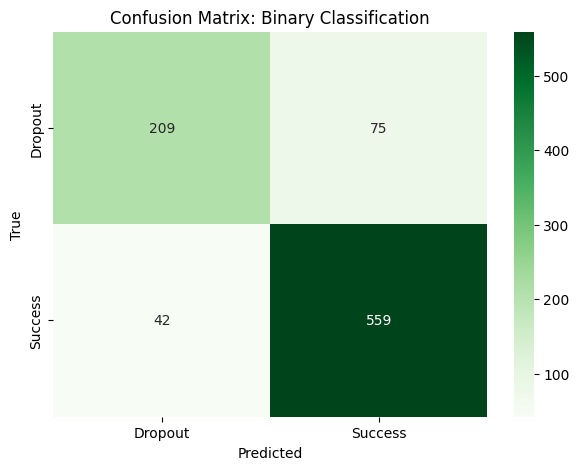

In [ ]:
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# 2. Initialize and train the binary model
weights = compute_sample_weight(class_weight='balanced', y=y_train_binary)
xgb_binary = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    objective='binary:logistic', # Changed to binary
    random_state=42,
    eval_metric='logloss'
)

xgb_binary.fit(X_train, y_train_binary)

# 3. Evaluation for Binary Classification
y_pred_binary = xgb_binary.predict(X_test)
target_names_binary = ['Dropout', 'Success']

print(f"--- Binary XGBoost Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test_binary, y_pred_binary):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_binary, y_pred_binary, target_names=target_names_binary))

# 4. Confusion Matrix Plot
plt.figure(figsize=(7, 5))
cm_binary = confusion_matrix(y_test_binary, y_pred_binary)
sns.heatmap(cm_binary, annot=True, fmt='d', cmap='Greens',
            xticklabels=target_names_binary,
            yticklabels=target_names_binary)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix: XGBoost')
plt.show()

In [ ]:
# Extracting importance for the binary model
xgb_bin_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_binary.feature_importances_
})

# Mapping descriptions
xgb_bin_importance['Description'] = xgb_bin_importance['Feature'].map(mapping_dict).fillna(xgb_bin_importance['Feature'])

# Sort and display Top 10
top_10_binary = xgb_bin_importance.sort_values(by='Importance', ascending=False).head(10)

print("=== Top 10 Features: Binary Classification ===")
print(top_10_binary[['Description', 'Importance']])

=== Top 10 Features: Binary Classification ===
                                       Description  Importance
14                             Credit_Success_Rate    0.186880
38       Course 171: Animation & Multimedia Design    0.079622
7               Financial: Tuition Paid up to Date    0.074054
120           Dad's Edu: Higher Education (Degree)    0.021970
13                                   Approved_Diff    0.020101
52                     Course 9853: Social Service    0.019565
10                  Demographic: Age at Enrollment    0.017365
6                    Financial: Debt Owed (Debtor)    0.016067
87            Mom's Edu: Higher Education (Degree)    0.015567
44   Course 9130: Equiniculture (Horse Management)    0.015066


In [ ]:
import pandas as pd
import numpy as np

def run_academic_risk_demo(model, feature_names, X_train):
    print("-" * 60)
    print("      GRADUATE VS. DROPOUT RISK ASSESSMENT")
    print("-" * 60)

    # Start with a baseline (median student)
    user_data = X_train.median().to_dict()

    print("Please provide student details:")

    # 1. Automatic Credit Rate Calculation
    try:
        taken = float(input("Number of courses enrolled last term (e.g., 5): ") or 5)
        passed = float(input("Number of courses passed last term (e.g., 4): ") or 4)
        user_data['Credit_Success_Rate'] = passed / taken if taken > 0 else 0
    except ValueError:
        user_data['Credit_Success_Rate'] = 0.8 # Fallback

    # 2. Automatic Mature Student Logic
    try:
        age = float(input("Student's age at enrollment (e.g., 18): ") or 18)
        user_data['Age at enrollment'] = age
        # Automatically determine "Mature Student" status
        user_data['Application mode_39'] = 1 if age > 23 else 0
    except ValueError:
        user_data['Age at enrollment'] = 18
        user_data['Application mode_39'] = 0

    # 3. Direct Binary Questions (Simple Yes/No)
    questions = [
        ('Tuition fees up to date', 'Are tuition fees fully paid? (1: Yes, 0: No): '),
        ('Scholarship holder', 'Is the student a scholarship holder? (1: Yes, 0: No): '),
        ('Debtor', 'Does the student have any outstanding debt? (1: Yes, 0: No): ')
    ]

    for feat, q in questions:
        val = input(q)
        user_data[feat] = float(val) if val.strip() != "" else user_data[feat]

    # 4. Major Selection
    print("\nSelect Major: [0] General [1] Animation [2] Social Service [3] Nursing")
    m_choice = input("Choice: ")
    for m in ['Course_171', 'Course_9853', 'Course_9500']: user_data[m] = 0
    if m_choice == '1': user_data['Course_171'] = 1
    elif m_choice == '2': user_data['Course_9853'] = 1
    elif m_choice == '3': user_data['Course_9500'] = 1

    # Final Prediction
    input_df = pd.DataFrame([user_data])[feature_names]
    prob = model.predict_proba(input_df)[0]
    pred = model.predict(input_df)[0]

    print("\n" + "="*40)
    status = "Success (Stay)" if pred == 1 else "Dropout (High Risk)"
    confidence = prob[1] if pred == 1 else prob[0]
    print(f"Prediction: {status}")
    print(f"Confidence: {confidence*100:.2f}%")
    print("="*40)

# run_academic_risk_demo(xgb_binary, X_train.columns, X_train)

# **ROC**

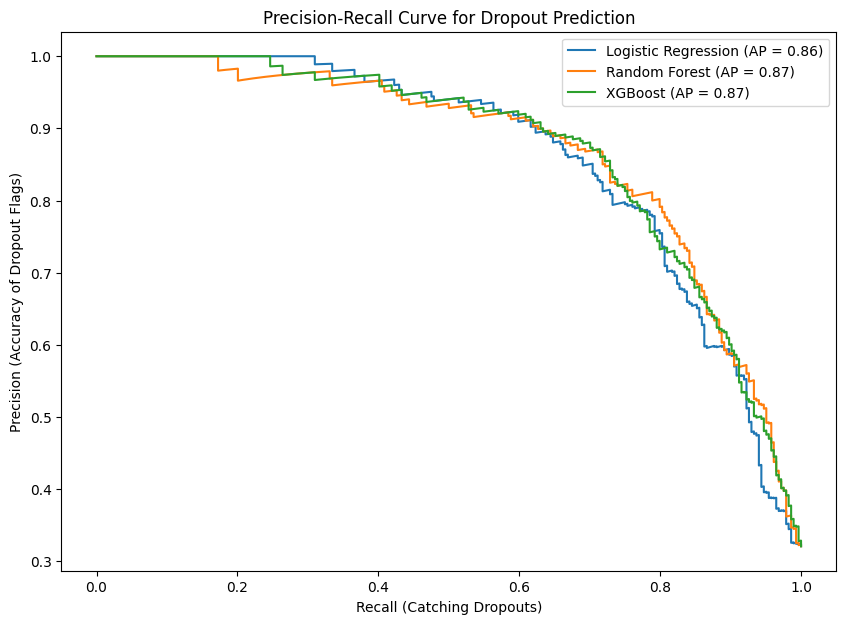

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

def plot_pr_curve(models, X_test, y_test):
    plt.figure(figsize=(10, 7))

    for name, model in models.items():
        # 獲取 Dropout (Class 0) 的預測機率
        # 注意：如果你的 y_test 裡 0 是 Dropout，機率通常是 probs[:, 0]
        # 但有些 Scikit-learn 函數預設看 Class 1，需確認你的編碼
        probs = model.predict_proba(X_test)[:, 0]

        # 計算 PR 數據 (這裡假設我們關注的是 Class 0: Dropout)
        # 如果要算 Dropout 的 Recall，y_true 需要轉換為: Dropout=1, Success=0
        y_true_dropout = (y_test == 0).astype(int)

        precision, recall, _ = precision_recall_curve(y_true_dropout, probs)
        ap_score = average_precision_score(y_true_dropout, probs)

        plt.plot(recall, precision, label=f'{name} (AP = {ap_score:.2f})')

    plt.xlabel('Recall (Catching Dropouts)')
    plt.ylabel('Precision (Accuracy of Dropout Flags)')
    plt.title('Precision-Recall Curve for Dropout Prediction')
    plt.legend(loc='best')
    plt.show()

# 使用方法：
models_dict = {
    "Logistic Regression": log_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_binary
}
plot_pr_curve(models_dict, X_test, y_test_binary)